# Direct Causal Cascade in the Stock Market  
### Reproducing Figures from Arnéodo, Muzy & Sornette (1998)

This notebook aims to reproduce, as closely as possible, the structure of Figures 1–3:

- **Figure 1:** log-price, centered log-volatility walk, shuffled version, and their autocorrelations.  
- **Figure 2:** log-volatility correlation vs log-lag for several scales.  
- **Figure 3:** mutual information cone across time and scale, for original and shuffled data.

Assumptions:
- Input data: CSV with columns `datetime, price` sampled at fixed interval (e.g. 5 minutes).
- We use a discrete wavelet transform with Haar wavelet to approximate the construction in the paper.


In [1]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8')
%matplotlib inline

from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]


# 0. convolve haar wavelet with itself

In [2]:
def build_haar_convolved_wavelet(order: int) -> pywt.Wavelet:
    haar = pywt.Wavelet("haar")
    base = np.array(haar.dec_lo)   # this is the Haar scaling filter
    filt = base.copy()
    for _ in range(order - 1):
        filt = np.convolve(filt, base)

    filt = filt / np.linalg.norm(filt)
    qmf = ((-1)**np.arange(len(filt))) * filt[::-1]

    return pywt.Wavelet(
        name=f"haar_conv_{order}",
        filter_bank=[filt, qmf, filt, qmf]
    )

In [3]:
conv_orders = [1, 2, 3, 4]
wavelet_dict = {order: build_haar_convolved_wavelet(order) for order in conv_orders}

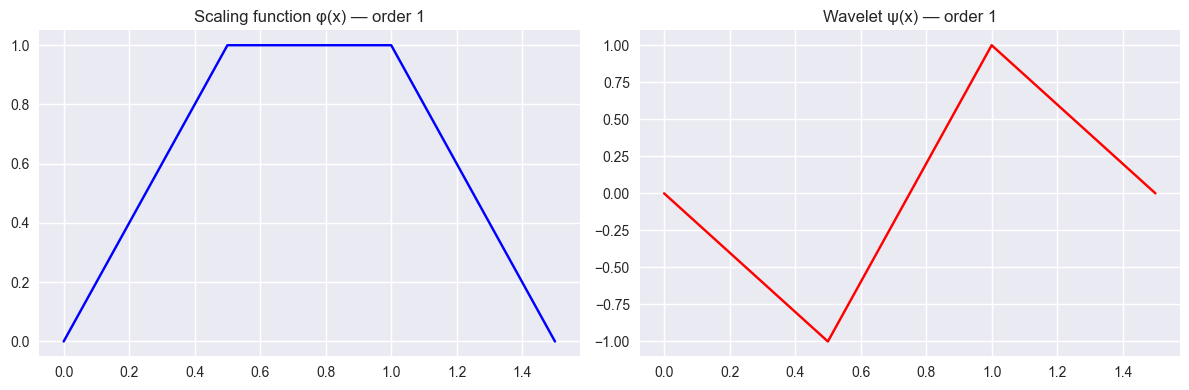

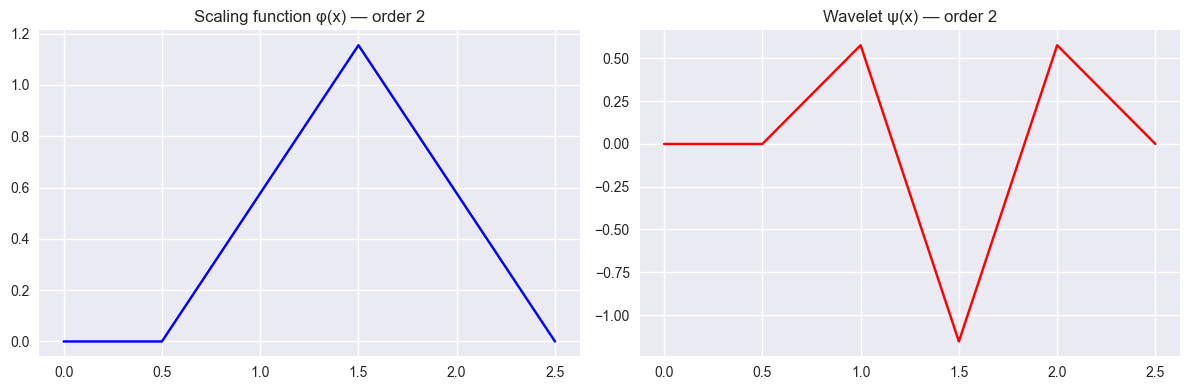

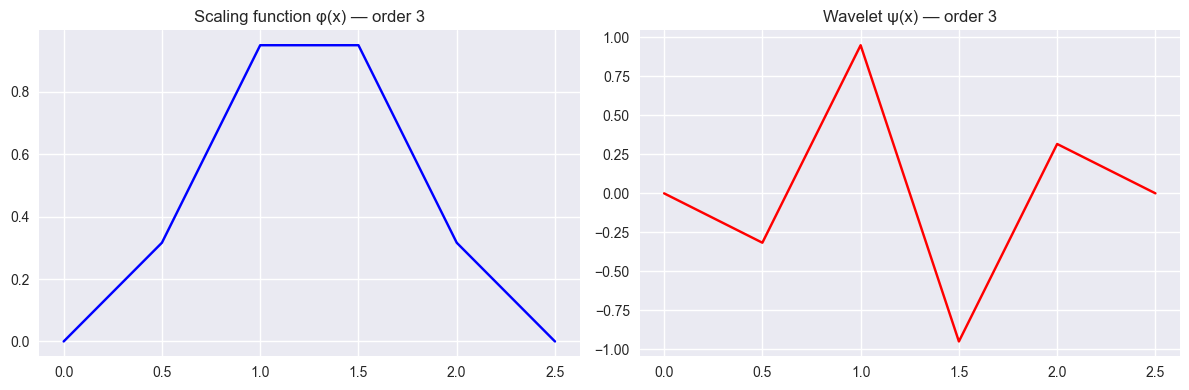

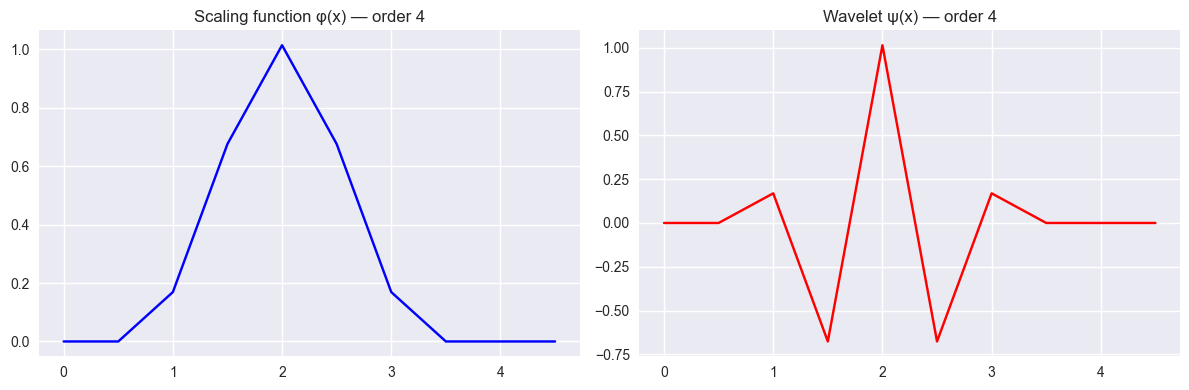

In [4]:
def plot_wfs():
    selected_order = len(conv_orders)

    for i in range(1,selected_order+1):
        wave = wavelet_dict[i]
    
        phi, psi,_,_, x = wave.wavefun(level=1)
    
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
        axes[0].plot(x, phi, color="blue")
        axes[0].set_title(f"Scaling function φ(x) — order {i}")
        axes[0].grid(True)
    
        axes[1].plot(x, psi, color="red")
        axes[1].set_title(f"Wavelet ψ(x) — order {i}")
        axes[1].grid(True)
    
        plt.tight_layout()
        plt.show()
plot_wfs()

## 1. Load and preprocess data

We:
- Load intraday prices
- Compute log-prices
- Remove intraday seasonality from 1-step returns
- Reconstruct a deseasonalized log-price series (used for all subsequent analysis)


In [5]:


DATA_PATH = "SandP_log2min.dat"   # one value per row

# Try reading with header; if no header, fallback
try:
    df = pd.read_csv(DATA_PATH)
    if df.shape[1] == 1:
        df.columns = ['price']
except:
    df = pd.read_csv(DATA_PATH, header=None)
    df.columns = ['price']

df = df.dropna().reset_index(drop=True)

# Log-price
df['log_price'] = np.log(df['price'])

# Since there is no intraday pattern, we skip deseasonalization
df['log_price_deseason'] = df['log_price']

df.head()



,price,log_price,log_price_deseason
0,9.710267,2.273184,2.273184
1,9.710085,2.273165,2.273165
2,9.709599,2.273115,2.273115
3,9.709478,2.273103,2.273103
4,9.709296,2.273084,2.273084


## 2. Wavelet transform and centered log-volatility walk

We:
- Apply a discrete wavelet transform (Haar) to the deseasonalized log-price.
- Use detail coefficients to define scale-dependent fluctuations.
- Build local volatility and log-volatility at each scale.
- Construct the centered log-volatility walk at a chosen scale (~20 minutes).


In [6]:
print(len(np.array(df['log_price_deseason'].values)[:-1]))
print(2**19)

640532
524288


In [7]:
wavelet = wavelet_dict[1] # 'haar'
max_level = 10
log_price = np.array(df['log_price_deseason'].values)[:2**19]

# DWT
coeffs = pywt.swt(log_price, wavelet, level=max_level)
scales = [2**i for i in range(1, max_level+1)]  # approximate scales

print("scales: ",scales)

print("different lengths of wavelet coefficient at each scale, because of downsampling")

print(coeffs)


def upsample_to_length(c_detail, level, original_len):
    return pywt.upcoef('d', c_detail, wavelet, level=level, take=original_len)

detail_series = []
for level in range(1, max_level+1):
    cD = coeffs[-level][1]
    # up = upsample_to_length(cD, level, len(log_price))
    detail_series.append(cD)

detail_series = np.array(detail_series)  # shape: (n_scales, n_time)
# print("\nafter upsampling")
print(detail_series.shape)


scales:  [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
different lengths of wavelet coefficient at each scale, because of downsampling
[(array([72.7921396 , 72.79221551, 72.79229221, ..., 72.80145285,
       72.79834876, 72.7952443 ], shape=(524288,)), array([0.02907455, 0.02901578, 0.02895852, ..., 0.01972054, 0.02283643,
       0.02595461], shape=(524288,))), (array([51.45125671, 51.45135195, 51.45144667, ..., 51.46445646,
       51.46005827, 51.4556582 ], shape=(524288,)), array([0.01967996, 0.01974929, 0.0198148 , ..., 0.00596746, 0.01054057,
       0.01511119], shape=(524288,))), (array([36.36761669, 36.36763501, 36.36765567, ..., 36.38664652,
       36.38030286, 36.37395962], shape=(524288,)), array([-0.0008219 , -0.00075271, -0.0006851 , ..., -0.02009473,
       -0.0136745 , -0.00725078], shape=(524288,))), (array([25.71636955, 25.71633358, 25.71630037, ..., 25.74345362,
       25.73442818, 25.72540058], shape=(524288,)), array([-0.0003542 , -0.00038354, -0.00041231, ..., -0.027255

In [8]:
for s in detail_series:
    print(s.shape)

(524288,)
(524288,)
(524288,)
(524288,)
(524288,)
(524288,)
(524288,)
(524288,)
(524288,)
(524288,)


## 3. Local volatility estimation

In [9]:
window = 50  # window for local volatility

vol_series = []
for s_idx in range(len(scales)):
    d = detail_series[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series.append(vol)

vol_series = np.array(vol_series)
log_vol_series = np.log(vol_series + 1e-12)

# Choose a scale index for ~20 min (adjust if your base step != 5 min)
scale_idx_20m = 3  # e.g. 2 * base step
w_a = log_vol_series[scale_idx_20m]
w_a_centered = w_a - np.mean(w_a)
v_a = np.cumsum(w_a_centered)

len(v_a)


524288

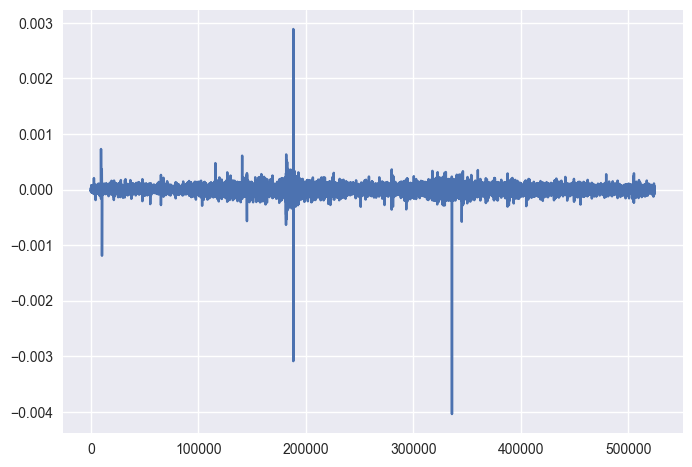

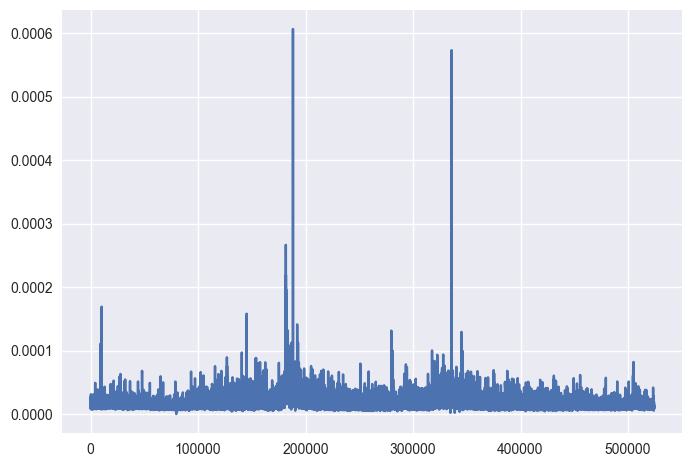

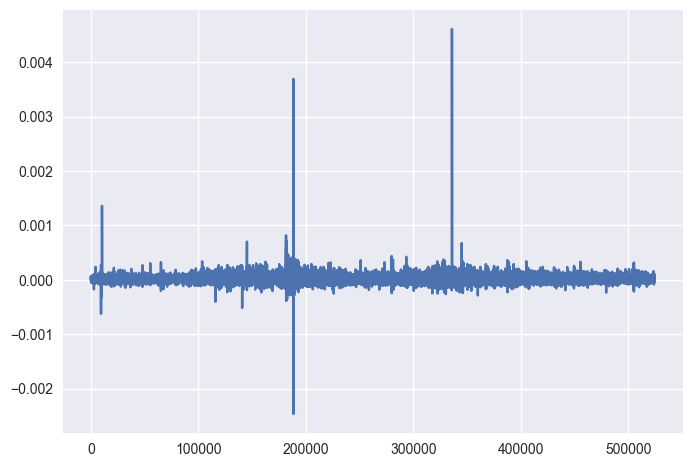

In [10]:
ind = 0
plt.plot(detail_series[ind][:-1])
plt.show()
plt.plot(vol_series[ind][:-1])
plt.show()
plt.plot(vol_series[ind][:-1]-detail_series[ind][:-1])
plt.show()

## 3. Figure 1: log-price, centered log-volatility walk, shuffled version

We now build the three time series:
- (a) log-price
- (b) centered log-volatility walk
- (c) same after shuffling the increments of log-price (as in the paper).


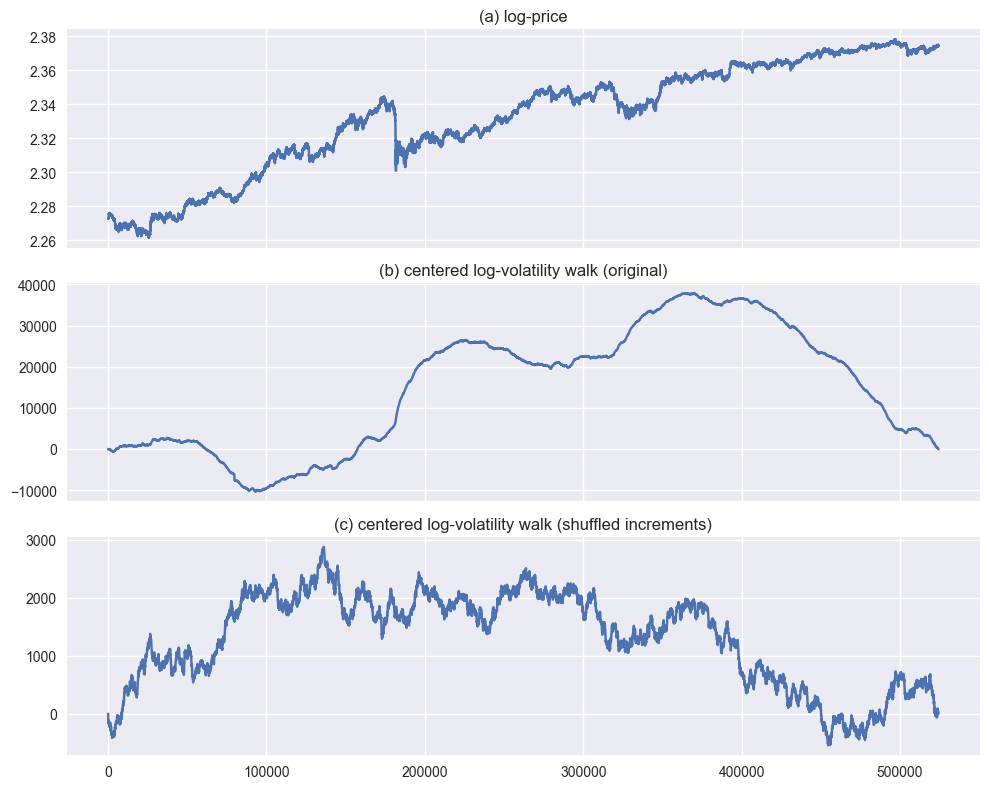

In [11]:
# (a) log-price
t = np.arange(len(log_price))
logP = log_price

# (c) shuffled increments version
increments = np.diff(logP)
shuffled_increments = np.random.permutation(increments)
logP_shuffled = np.concatenate([[logP[0]], logP[0] + np.cumsum(shuffled_increments)])

# Recompute wavelet-based log-volatility walk for shuffled series
coeffs_sh = pywt.wavedec(logP_shuffled, wavelet, level=max_level)
detail_series_sh = []
for level in range(1, max_level+1):
    cD = coeffs_sh[-level]
    up = upsample_to_length(cD, level, len(logP_shuffled))
    detail_series_sh.append(up)
detail_series_sh = np.array(detail_series_sh)

vol_series_sh = []
for s_idx in range(len(scales)):
    d = detail_series_sh[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh.append(vol)
vol_series_sh = np.array(vol_series_sh)
log_vol_series_sh = np.log(vol_series_sh + 1e-12)

w_a_sh = log_vol_series_sh[scale_idx_20m]
w_a_sh_centered = w_a_sh - np.mean(w_a_sh)
v_a_sh = np.cumsum(w_a_sh_centered)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, logP)
axes[0].set_title('(a) log-price')

axes[1].plot(t, v_a)
axes[1].set_title('(b) centered log-volatility walk (original)')

axes[2].plot(t, v_a_sh)
axes[2].set_title('(c) centered log-volatility walk (shuffled increments)')

plt.tight_layout()
plt.show()


## 4. Autocorrelation of returns vs log-volatility

### Figure 1′: Autocorrelations (returns and log-volatility)

We compute:
- (a′) autocorrelation of 1-step returns
- (b′) autocorrelation of log-volatility at scale ~20 min
- (c′) same for shuffled series


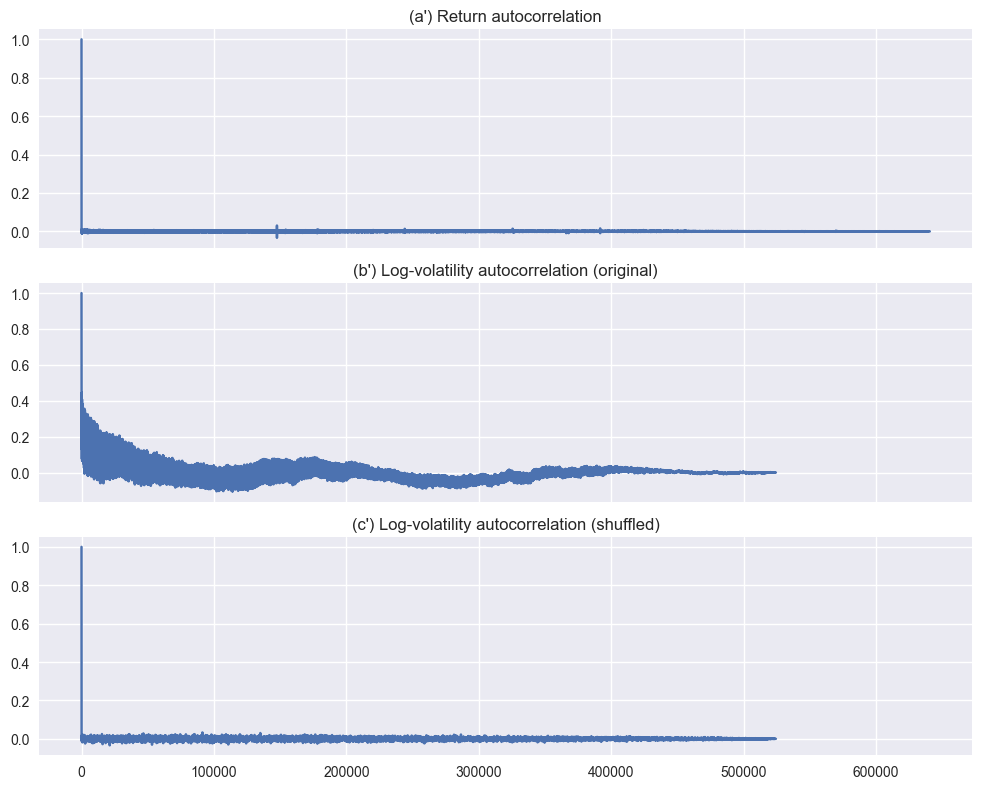

In [12]:
from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]

def corr_function(x, max_lag):
    """
    Normalized autocorrelation function C(Δt) for a 1D series x,
    for lags 0..max_lag.
    """
    x = np.asarray(x, float)
    n = len(x)

    # raw autocovariance via FFT convolution
    c = covariance_fft(x)

    # unbiased normalization by number of overlapping points
    norm = np.arange(n, 0, -1)
    c = c / norm

    # normalize to get correlation function: C(0) = 1
    c = c / c[0]

    return c[:max_lag + 1]

def autocorr(x, max_lag):
    x = x - np.mean(x)
    var = np.var(x)
    ac = []
    for lag in range(max_lag+1):
        if lag == 0:
            ac.append(1.0)
        else:
            ac.append(np.dot(x[:-lag], x[lag:]) / ((len(x)-lag)*var))
    return np.array(ac)

max_lag = 500

# (a′) return autocorrelation
ret = np.diff(df['log_price_deseason'].values)
ret_ac = covariance_fft(ret)

# (b′) log-volatility autocorrelation (original)
w = w_a
w_ac = covariance_fft(w)

# (c′) log-volatility autocorrelation (shuffled)
w_sh = w_a_sh
w_sh_ac = covariance_fft(w_sh)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(ret_ac)
axes[0].set_title("(a') Return autocorrelation")

axes[1].plot(w_ac)
axes[1].set_title("(b') Log-volatility autocorrelation (original)")

axes[2].plot(w_sh_ac)
axes[2].set_title("(c') Log-volatility autocorrelation (shuffled)")

plt.tight_layout()
plt.show()


## 4. Figure 2: Log-volatility correlation vs log-lag for several scales(TODO - wrong figure)

We:
- Choose several scales (e.g. small, medium, large)
- Compute autocorrelation of log-volatility at each scale
- Plot correlation vs \\(\\ln \\Delta t\\) and show the collapse.


In [13]:
# Choose a few scale indices (adjust depending on your sampling)
scale_indices = [2, 16, 128]  # example: smaller, medium, larger scales
labels = [f'scale ~ {scales[i]}' for i in scale_indices]

max_lag_fig2 = 1000
lags = np.arange(1, max_lag_fig2+1)

plt.figure(figsize=(10, 5))
for idx, lab in zip(scale_indices, labels):
    w_s = log_vol_series[idx]          # this is ω_a(t)
    C = corr_function(w_s,max_lag_fig2)
    # skip lag 0, plot Δt = 1..max_lag
    plt.scatter(np.log(lags), C[1:], s=5, label=lab)

plt.xlabel('ln(Δt)')
plt.ylabel('Correlation')
plt.title('Figure 2: log-volatility correlation vs ln(Δt) for several scales')
plt.legend()
plt.tight_layout()
plt.show()


IndexError: list index out of range

## 5. Figure 3: Mutual information cone across time and scale (TODO - doesn't seem to show what was shown in the paper)

We compute the mutual information between log-volatility at different scales and times, using the Gaussian approximation:

\

\[
I = -\\frac{1}{2} \\log(1 - \\rho^2),
\\]



where \\(\\rho\\) is the Pearson correlation.


2010
Progress: 1/2010
Progress: 11/2010
Progress: 21/2010
Progress: 31/2010
Progress: 41/2010
Progress: 51/2010
Progress: 61/2010
Progress: 71/2010
Progress: 81/2010
Progress: 91/2010
Progress: 101/2010
Progress: 111/2010
Progress: 121/2010
Progress: 131/2010
Progress: 141/2010
Progress: 151/2010
Progress: 161/2010
Progress: 171/2010
Progress: 181/2010
Progress: 191/2010
Progress: 201/2010
Progress: 211/2010
Progress: 221/2010
Progress: 231/2010
Progress: 241/2010
Progress: 251/2010
Progress: 261/2010
Progress: 271/2010
Progress: 281/2010
Progress: 291/2010
Progress: 301/2010
Progress: 311/2010
Progress: 321/2010
Progress: 331/2010
Progress: 341/2010
Progress: 351/2010
Progress: 361/2010
Progress: 371/2010
Progress: 381/2010
Progress: 391/2010
Progress: 401/2010
Progress: 411/2010
Progress: 421/2010
Progress: 431/2010
Progress: 441/2010
Progress: 451/2010
Progress: 461/2010
Progress: 471/2010
Progress: 481/2010
Progress: 491/2010
Progress: 501/2010
Progress: 511/2010
Progress: 521/2010

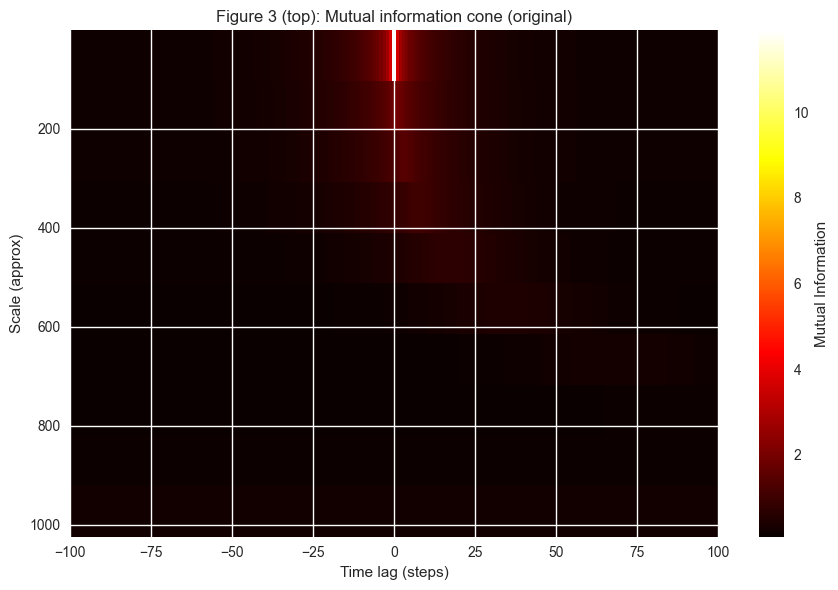

In [14]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import multiprocess as mp

# -----------------------------
# 1. Precompute centered series
# -----------------------------
max_time_lag = 100
ref_idx = 0  # smallest scale as reference

w_a_centered_list = [log_vol - np.mean(log_vol) for log_vol in log_vol_series]
w_ref = w_a_centered_list[ref_idx]

I_map = np.zeros((len(scales), 2*max_time_lag+1))

# -----------------------------
# 2. Worker function
# -----------------------------
def compute_I(args):
    """
    args = (s_idx, dt, w_a_centered_list, w_ref)
    Everything is passed explicitly so workers don't rely on notebook globals.
    """
    import numpy as np
    from sklearn.feature_selection import mutual_info_regression

    s_idx, dt, w_list, w_ref_local = args

    w_other = w_list[s_idx]

    # Align time series depending on lag
    if dt >= 0:
        x = w_other[:-dt or None]
        y = w_ref_local[dt:]
    else:
        x = w_other[-dt:]
        y = w_ref_local[:dt or None]

    # Too short → skip
    if len(x) < 10:
        return 0.0

    # Compute MI
    I = mutual_info_regression(x.reshape(-1,1), y, n_jobs=1)
    return float(I[0])

# -----------------------------
# 3. Build task list
# -----------------------------
tasks = [
    (s_idx, dt, w_a_centered_list, w_ref)
    for s_idx in range(len(scales))
    for dt in range(-max_time_lag, max_time_lag+1)
]
print(len(tasks))
# -----------------------------
# 4. Run multiprocessing
# -----------------------------
results = []
with mp.Pool(mp.cpu_count()) as pool:
    for i, result in enumerate(pool.imap(compute_I, tasks)):
        results.append(result)
        if i%10==0:
            print(f"Progress: {i + 1}/{len(tasks)}")

# -----------------------------
# 5. Fill I_map
# -----------------------------
for i, (s_idx, dt, _, _) in enumerate(tasks):
    I_map[s_idx, dt + max_time_lag] = results[i]

    

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()


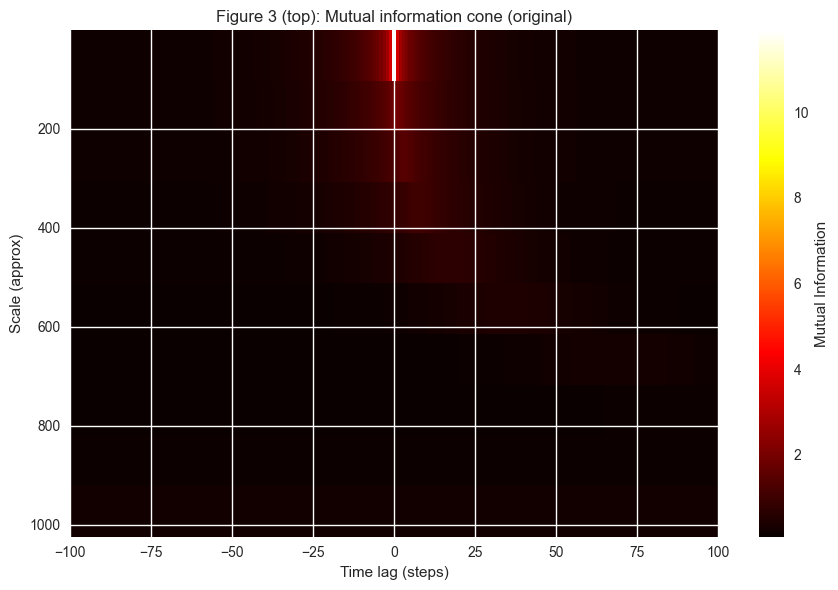

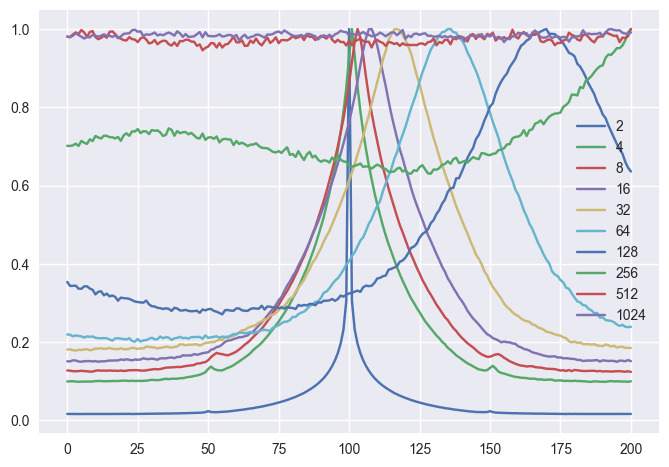

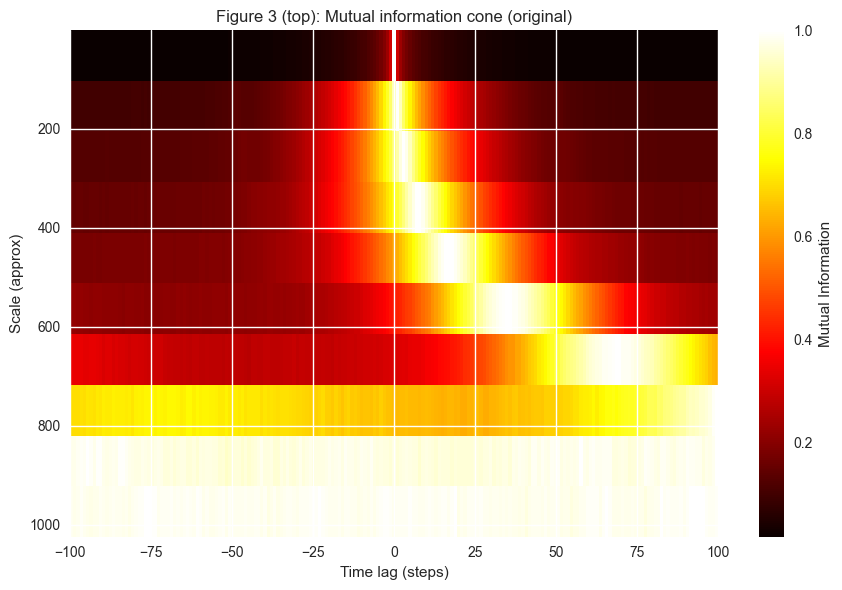

In [15]:

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()


I_normalized = []
for i,I in enumerate(I_map):
    I_normalized.append(I/np.max(I))
    plt.plot(I_normalized[i],label=scales[i])

plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_normalized, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

In [ ]:
I_map_slow = np.load("I_map_paper.npy")

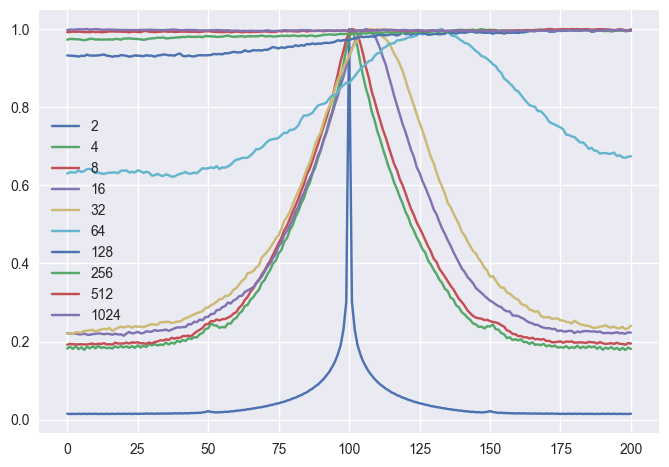

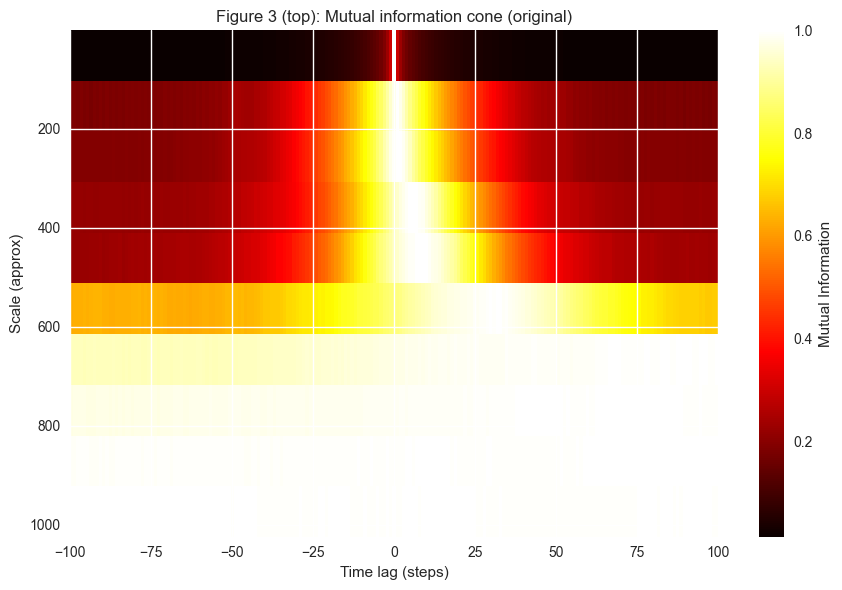

In [ ]:
I_normalized_slow = []
for i,I in enumerate(I_map_slow):
    I_normalized_slow.append(I/np.max(I))
    plt.plot(I_normalized_slow[i],label=scales[i])

plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
extent = [-100, 100, scales[-1], scales[0]]
plt.imshow(I_normalized_slow, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

### Shuffled control for Figure 3 (TODO)

We repeat the mutual information computation for the shuffled series, which should destroy the cascade structure and yield a noisy, structureless map.


In [ ]:
logP_shuffled2 = logP_shuffled  # from earlier
coeffs_sh2 = pywt.wavedec(logP_shuffled2, wavelet, level=max_level)

detail_series_sh2 = []
for level in range(1, max_level+1):
    cD = coeffs_sh2[-level]
    up = upsample_to_length(cD, level, len(logP_shuffled2))
    detail_series_sh2.append(up)
detail_series_sh2 = np.array(detail_series_sh2)

vol_series_sh2 = []
for s_idx in range(len(scales)):
    d = detail_series_sh2[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh2.append(vol)
vol_series_sh2 = np.array(vol_series_sh2)
log_vol_series_sh2 = np.log(vol_series_sh2 + 1e-12)

w_ref_sh = log_vol_series_sh2[ref_idx]
I_map_sh = np.zeros((len(scales), 2*max_time_lag+1))

for s_idx in range(len(scales)):
    w_other = log_vol_series_sh2[s_idx]
    for dt in range(-max_time_lag, max_time_lag+1):
        if dt >= 0:
            x = w_other[:-dt or None]
            y = w_ref_sh[dt:]
        else:
            x = w_other[-dt:]
            y = w_ref_sh[:dt or None]
        if len(x) < 10:
            I = 0
        else:
            I = gaussian_MI(x, y)
        I_map_sh[s_idx, dt + max_time_lag] = I

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map_sh, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (bottom): Mutual information cone (shuffled)')
plt.tight_layout()
plt.show()
